# FoldForge - The Origamizer: fold any 3D shape

The capstone. Give FoldForge a target - a cross-section, a height field, an
analytic surface, or even an image - and it designs the pleated sheet that folds
into it, reusing the differentiable inverse-design core (M2/M3).

Method: model the sheet as parallel rigid **fold chains** and solve each chain's
fold angles so its cross-section matches the target. Every intermediate fold is
an exact rigid state, so the sheet genuinely folds *onto* the target.

## 1. A profile -> an exactly-developable pleated sheet

Give it a dome cross-section; it returns a real crease pattern (a FOLD file) and
the folded shape. This case is exactly developable - a genuine flat-foldable
sheet.

pleats: 28  match error (Chamfer): 0.0493
flat-foldable crease pattern: True


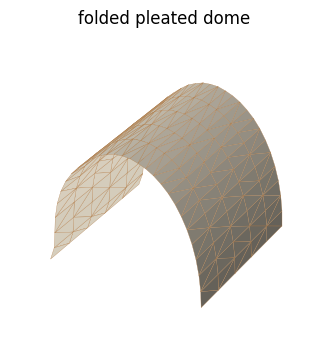

In [1]:
import numpy as np, matplotlib.pyplot as plt
from foldforge.origamize import origamize_profile, profile_dome
from foldforge import foldability_report

r = origamize_profile(profile_dome())
print("pleats:", len(r.angles), " match error (Chamfer):", round(r.error, 4))
print("flat-foldable crease pattern:", foldability_report(r.pattern).flat_foldable)

f = r.folded
ax = plt.figure(figsize=(6,4)).add_subplot(111, projection="3d")
ax.plot_trisurf(f[:,0], f[:,1], f[:,2], color="#ece3d0", edgecolor="#b07a45", linewidth=0.2)
ax.set_title("folded pleated dome"); ax.set_axis_off(); plt.show()

## 2. A full 3D height field -> folding onto the target

Each row of the surface is origamized independently into a pleated strip. Watch
the sheet fold from flat onto the target dome (cyan = target).

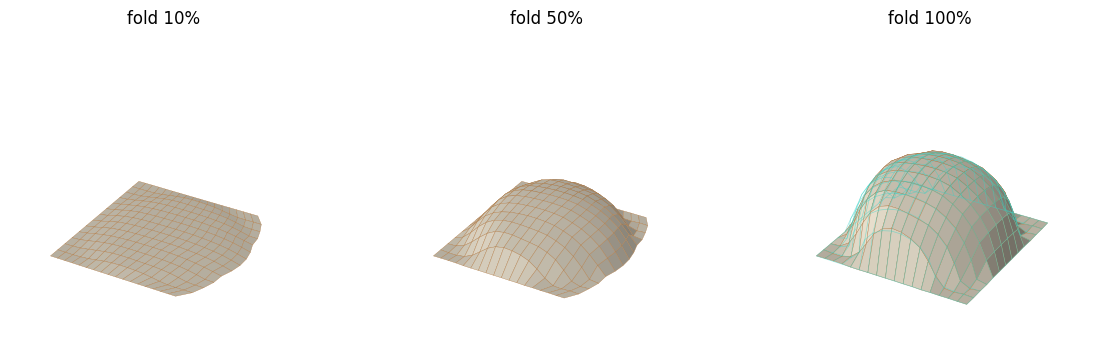

In [2]:
from foldforge.design.inverse import fit_chain, resample_arclength
from foldforge.diff.kinematics import fold_chain
from foldforge.origamize import heightfield_dome

Z = heightfield_dome(nx=18, ny=14, height=6.0); ny, nx = Z.shape
xs = np.linspace(0, 24, nx); ys = np.linspace(0, 20, ny)
rows, target = [], np.zeros((ny, nx, 3))
for j in range(ny):
    tgt = resample_arclength(np.stack([xs, Z[j]], axis=1), nx-1)
    seg = float(np.linalg.norm(np.diff(tgt, axis=0), axis=1).mean())
    rows.append((fit_chain(tgt, seg=seg, iters=400).angles, seg))
    target[j,:,0]=tgt[:,0]; target[j,:,1]=ys[j]; target[j,:,2]=tgt[:,1]
ctr = target.reshape(-1,3).mean(0); target -= ctr
def frame(fr):
    V=np.zeros((ny,nx,3))
    for j,(a,s) in enumerate(rows):
        sp=fold_chain(fr*a, seg=s).spine; V[j,:,0]=sp[:,0]; V[j,:,1]=ys[j]; V[j,:,2]=sp[:,1]
    return V-ctr
fig=plt.figure(figsize=(14,4))
for k,fr in enumerate([0.1,0.5,1.0]):
    V=frame(fr); ax=fig.add_subplot(1,3,k+1,projection="3d")
    ax.plot_surface(V[:,:,0],V[:,:,1],V[:,:,2],color="#ece3d0",edgecolor="#b07a45",lw=0.25)
    if fr==1.0: ax.plot_wireframe(target[:,:,0],target[:,:,1],target[:,:,2],color="#39d3c7",lw=0.5,alpha=0.5)
    ax.set_title(f"fold {fr:.0%}"); ax.set_axis_off(); ax.set_zlim(-3,7)
plt.show()

## 3. Fold an image

Brightness becomes height: estimate a relief from a picture and fold it. (Here a
synthesised smiley; pass a file path to fold your own.)

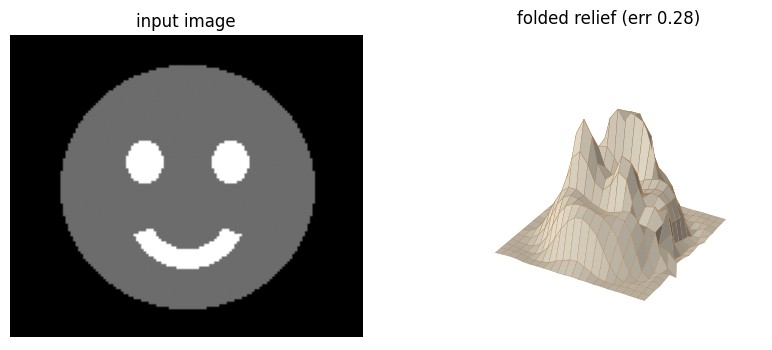

In [3]:
from PIL import Image, ImageDraw
from foldforge.origamize import origamize_image
im = Image.new("L",(140,120),20); d=ImageDraw.Draw(im)
d.ellipse([20,12,120,108],fill=120); d.ellipse([46,42,60,58],fill=255)
d.ellipse([80,42,94,58],fill=255); d.arc([48,52,92,92],20,160,fill=255,width=8)
arr = np.asarray(im, float)/255
r = origamize_image(arr, grid=(18,22), iters=350)
ny,nx = 18,22; F = r.folded.reshape(ny,nx,3)
fig=plt.figure(figsize=(10,4))
ax=fig.add_subplot(1,2,1); ax.imshow(arr,cmap="gray"); ax.set_title("input image"); ax.axis("off")
ax=fig.add_subplot(1,2,2,projection="3d")
ax.plot_surface(F[:,:,0],F[:,:,1],F[:,:,2],color="#ece3d0",edgecolor="#b07a45",lw=0.2)
ax.set_title(f"folded relief (err {r.error:.2f})"); ax.set_axis_off(); plt.show()

## Recap

One pipeline folds **any** input - profile, height field, surface, image, or
mesh point cloud - by decomposing it into pleated fold-chains and solving their
angles with the differentiable core. Profiles are exactly developable; full 3D
height fields are honest corrugation approximations with the error reported.
Open `studio/index.html` to fold these shapes interactively in 3D.